# Reconstruction on anticyclonic and cyclonic structures


In [8]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
    drifters_structure,
)
from diagnosis import (
    generate_0_15m_coloc_dataframe,
    sel_structure,
    compute_variance_groupby,
    compute_variance,
    prepared_alti,
    put_fig_letter,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine


from diagnosis import synthetic_figure
from cstes import U2, c0, structure

depthcolor = {0: "navy", 15: "green", 50: "yellowgreen", 100: "yellow"}

In [62]:
def print_labels(df, ax, plot_reserror_cor=False):
    S = df.X_cor_ggd
    l = ["X_acc_cor", "X_acc_ggd", "X_cor_ggd"]
    for i in range(len(l)):
        X = l[i]
        label = (
            rf"{np.round(df[X].values[0], 2)}"
            + rf"$\pm$ {np.round(df['er__' + X].values[0], 2)}"
        )
        if i in [0, 1]:
            label = label + "\n" + f"{int(np.round((df[X]/S*100).values[0], 0))}%"
        if X == "E_cor":
            vpos, i = df[X].values + df.X_cor_ggd, 2
        elif plot_reserror_cor & (df[X].values > 2):
            vpos = df[X].values / 2
        else:
            vpos = df[X].values + 1
        ax.text(
            i,
            vpos,
            label,
            horizontalalignment="center",
            verticalalignment="center",
            rotation=0,
        )


def plot_one_axis(df_, ax, plot_reserror_cor=False):
    plt.rcParams["hatch.linewidth"] = 6
    kwargs = dict(hatch="/", width=0.8, capsize=2)
    plt.rcParams["hatch.color"] = c0["cor"]

    plt.rcParams["hatch.color"] = c0["cor"]
    ax.bar(0, df_.X_acc_cor, color=c0["acc"], yerr=df_["er__X_acc_cor"], **kwargs)

    plt.rcParams["hatch.color"] = c0["ggd"]
    ax.bar(1, df_.X_acc_ggd, color=c0["acc"], yerr=df_["er__X_acc_ggd"], **kwargs)

    plt.rcParams["hatch.color"] = c0["ggd"]
    ax.bar(2, df_.X_cor_ggd, color=c0["cor"], yerr=df_["er__X_cor_ggd"], **kwargs)
    if plot_reserror_cor:
        plt.rcParams["hatch.color"] = "lightgrey"
        ax.bar(
            2,
            df_.E_cor * 2,
            bottom=df_.X_cor_ggd,
            yerr=df_.er__E_cor * 2,
            color=c0["cor"],
            alpha=0.5,
            **kwargs,
        )

    # plt.rcParams["hatch.color"] = c0['cor']
    # ax.bar(3, df_.X_cor_wd, color = c0['wd'], yerr =df_['er__X_cor_wd'], **kwargs)

    # plt.rcParams["hatch.color"] = c0['acc']
    # ax.bar(4, df_.X_acc_wd, color = c0['wd'], yerr =df_['er__X_acc_wd'], **kwargs)

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(5, df_.X_ggd_wd, color = c0['wd'], yerr =df_['er__X_ggd_wd'], **kwargs)

    ax.grid()
    ax.set_ylabel(rf"Paired contributions [$\gamma^2$]")
    ax.set_xticks(
        [0, 1, 2],
        [
            "Lagrangian \n -Coriolis \n accelerations \n pair",
            "Lagrangian \n acceleration \n - Pressure gradient\n term pair",
            "Geostrophic \n pair",
        ],
    )  # , ha='right')
    print_labels(df_, ax, plot_reserror_cor)

In [61]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(
        data=nsamples,
        dims=[y, x],
        coords={x: ([x], (xx[:-1] + xx[1:]) / 2), y: ([y], (yy[:-1] + yy[1:]) / 2)},
    )
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))

    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )

    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    from matplotlib import colors

    da.plot.pcolormesh(
        ax=ax,
        norm=colors.LogNorm(),
        vmin=1e0,
        add_colorbar=False,
    )
    da.plot.contour(ax=ax, add_colorbar=False, colors="orange")
    ax.plot(xx, xx, color="r")
    # ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color="r")
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )

    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title("")
    ax_histx.set_title("")
    ax_histy.set_xlabel("")
    ax_histx.set_xlabel("")
    return fig, ax, ax_histx, ax_histy
    # fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


def plot_join_pdfs_one(ds, x, y, binx=100, biny=100, ax=None):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(
        data=nsamples,
        dims=[y, x],
        coords={x: ([x], (xx[:-1] + xx[1:]) / 2), y: ([y], (yy[:-1] + yy[1:]) / 2)},
    )
    plt.rcParams["axes.edgecolor"] = "k"

    from matplotlib import colors

    da.where(da != 0).plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0)
    da.plot.contour(ax=ax, add_colorbar=False, colors="orange")
    ax.plot(xx, xx, color="r")
    # ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color="r")
    ax.grid()

## Data 

In [15]:
df0, df15 = generate_0_15m_coloc_dataframe("LF", DT=12)
df0 = df0[(df0.drifter_type != "SPOTTER") & (df0.drifter_type != "MELODI")]

df0["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df0.latitude * np.pi / 180)
df15["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df15.latitude * np.pi / 180)

12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [16]:
df0 = df0[df0.depth != 100]
df0 = df0[df0.depth != 50]

In [17]:
cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))
cutoff

[4000.0,
 6000.0,
 8000.0,
 10000.0,
 12000.0,
 14000.0,
 16000.0,
 18000.0,
 20000.0,
 25000.0,
 30000.0,
 35000.0,
 40000.0,
 45000.0,
 50000.0,
 55000.0]

In [48]:
dfs = prepared_alti(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="gaussian_aviso",
    alti_diff_method_param=int(110e3),
)


def concat(df, dfs, from_="mano"):
    df = pd.concat(
        [
            df,
            dfs[
                [
                    "vorticity_etaf",
                    "strain_s_etaf",
                    "strain_n_etaf",
                ]
            ],
        ],
        axis=1,
    ).dropna()
    df["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    # From computation
    if from_ == "mano":
        df["strain_f"] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
        df["strain"] = (
            df.strain_f * df.f
        )  # .assign_attrs({'long_name':r'$\sigma/|f|$'})
        df["vorticity"] = (
            df.vorticity_etaf * df.f
        )  # .assign_attrs({'long_name':r'$\zeta/f$'})
        df[
            "vorticity_f"
        ] = df.vorticity_etaf  # .assign_attrs({'long_name':r'$\zeta/f$'})
        df["omega"] = df.strain**2 - df.vorticity**2
    # From duacs
    elif from_ == "duacs":
        df["strain_f"] = dfs.duacs_strain / df.f
        df["strain"] = df.strain_f * df.f
        df["vorticity_f"] = dfs.duacs_relative_vorticity
        df["vorticity"] = df.vorticity_f * df.f
        df["omega"] = df.strain**2 - df.vorticity**2
    return df


df0_ = concat(df0, dfs)
df15_ = concat(df15, dfs)

## Cyclogeostrophy (not looking at Ekman term as depend on depth)

In [49]:
# Cyclone
dfc = pd.concat(
    [
        sel_structure(df0_, **structure[c])
        for c in [k for k in structure if "Cyclone" in k]
    ]
)
dsc = dfc.to_xarray()
dsc["id_comb"] = dsc["id_comb"].isel(row_number=0)
dsc = dsc.set_coords("id_comb").expand_dims("id_comb")
dmc = compute_variance(dsc, compute_error="centrallimit") / U2

# Anticyclone
dfa = pd.concat(
    [
        sel_structure(df0_, **structure[c])
        for c in [k for k in structure if "nticyclone" in k]
    ]
)
dsa = dfa.to_xarray()
dsa["id_comb"] = dsa["id_comb"].isel(row_number=0)
dsa = dsa.set_coords("id_comb").expand_dims("id_comb")
dma = compute_variance(dsa, compute_error="centrallimit") / U2

# All
ds = df0_.to_xarray()
ds["id_comb"] = ds["id_comb"].isel(row_number=0)
ds = ds.set_coords("id_comb").expand_dims("id_comb")
dm = compute_variance(ds, compute_error="centrallimit") / U2

# Not in cyclone or anticyclone
dfn = df0_[~df0_.isin(dfa)].dropna()
dfn = dfn[~dfn.isin(dfc)].dropna()
dsn = dfn.to_xarray()
dsn["id_comb"] = dsn["id_comb"].isel(row_number=0)
dsn = dsn.set_coords("id_comb").expand_dims("id_comb")
dn = compute_variance(dsn, compute_error="centrallimit") / U2

49
640
2447
1805


In [50]:
dfc.f.mean()

9.449270108409619e-05

0.17128594115445944
6.6360199897488465
0.14099435287329132
12.334686774941995


[Text(0, -1.0, ''),
 Text(0, 0.0, ''),
 Text(0, 1.0, ''),
 Text(0, 2.0, ''),
 Text(0, 3.0, ''),
 Text(0, 4.0, ''),
 Text(0, 5.0, ''),
 Text(0, 6.0, ''),
 Text(0, 7.0, '')]

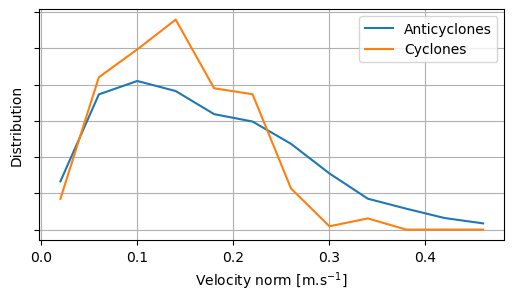

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/matplotlib/_tight_bbox.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  fig.patch.set_bounds(x0 / w1, y0 / h1,
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/matplotlib/_tight_bbox.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  fig.bbox.width / w1, fig.bbox.height / h1)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/matplotlib/patches.py:742: RuntimeWarning: invalid value encountered in scalar add
  x1 = self.convert_xunits(self._x0 + self._width)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/matplotlib/patches.py:743: RuntimeWarning: invalid value encountered in scalar add
  y1 = self.convert_yunits(self._y0 + self._height)


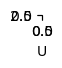

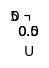

In [51]:
def plot_pdfs(v, ax, bins, label):
    f, m = plt.subplots(figsize=(0, 0))
    h, b, _ = (
        df_[v]
        .to_xarray()
        .plot.hist(
            bins=bins,
            ax=m,
            density=True,
        )
    )
    b = (b[1:] + b[:-1]) / 2
    ax.plot(b, h, label=label)


fig, ax = plt.subplots(figsize=(6, 3))

df_ = dfc
i = 0
l = [
    "Anticyclones",
    "Cyclones",
]
for df_ in [dfa, dfc]:
    df_["U"] = np.sqrt((df_.core**2 + df_.corn**2) / (df_.f**2))
    print(df_["U"].mean())
    print(df_.depth.mean())
    plot_pdfs("U", ax, np.arange(0, 0.5, 0.04), l[i])
    i += 1

ax.grid()
ax.legend()
ax.set_xlabel(r"Velocity norm [m.s$^{-1}$]")
ax.set_ylabel(r"Distribution")
ax.set_yticklabels([])

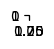

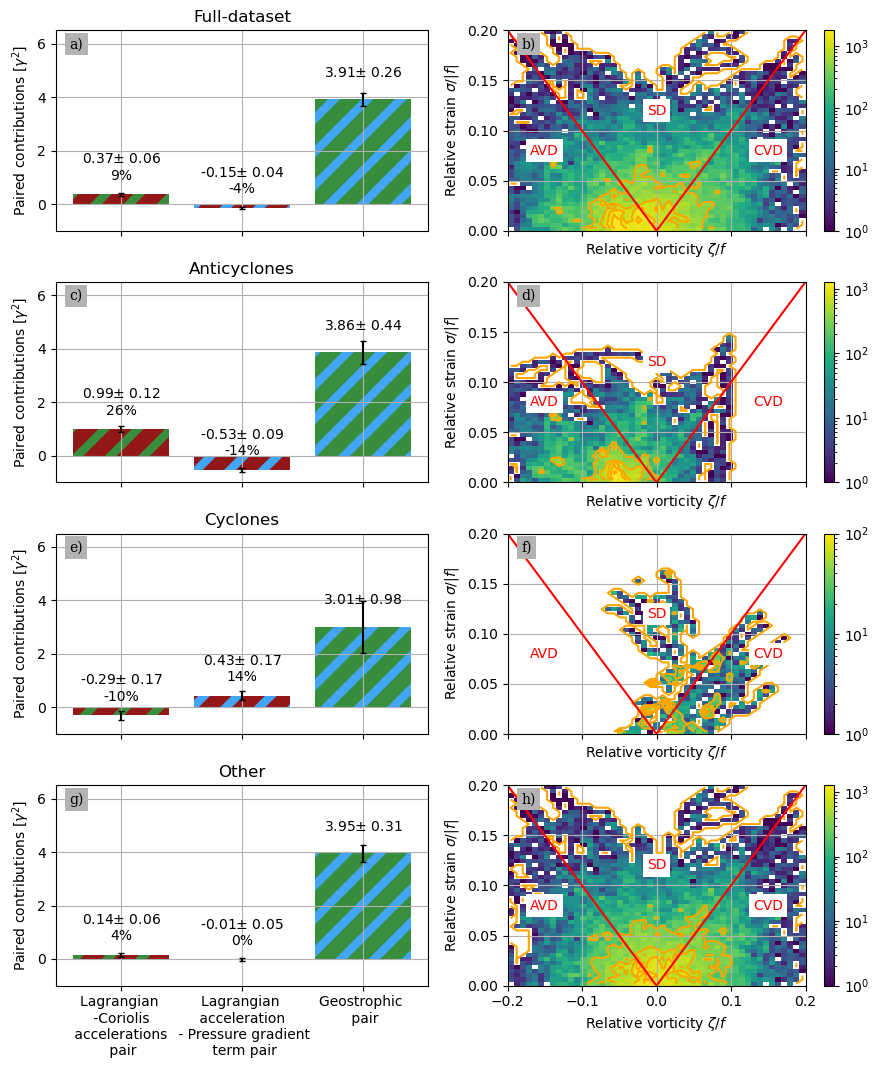

In [63]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
# ax.bar(0,1, color=c0['ggd'], label='Pressure gradient')
# ax.bar(0,1, color=c0['wd'], label='Wind term')
# ax.bar(0,1, color='lightgrey', label='Balanced Coriolis resolution mismatch error ?')
plt.rcParams["hatch.color"] = "lightgrey"
ax.bar(
    1,
    1,
    color=c0["cor"],
    alpha=0.5,
    hatch="/",
    label="Potential balance with Coriolis acceleration resolution mismatch error",
)

handles, labels = ax.get_legend_handles_labels()

plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(
    4, 2, frameon=False, figsize=(9, 11), sharex="col", sharey="col"
)

axs = axs.T.flatten()

# X_
plot_reserror_cor = False
plot_one_axis(dm, axs[0], plot_reserror_cor)
axs[0].set_title("Full-dataset")
plot_one_axis(dma, axs[1], plot_reserror_cor)
axs[1].set_title("Anticyclones")
plot_one_axis(dmc, axs[2], plot_reserror_cor)
axs[2].set_title("Cyclones")
plot_one_axis(dn, axs[3], plot_reserror_cor)
axs[3].set_title("Other")

# Vorticity-strain diagram
binx = np.linspace(-0.2, 0.2, 50)
biny = np.linspace(0, 0.2, 50)
ax = axs[4]
plot_join_pdfs_one(df0_, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")
kwa = dict(
    c="r", bbox=dict(facecolor="w", edgecolor="none", pad=3.0), va="center", ha="center"
)


ax = axs[5]
plot_join_pdfs_one(dfa, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")
ax.set_ylim(0, 1.25)

ax = axs[6]
plot_join_pdfs_one(dfc, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")

ax = axs[7]
plot_join_pdfs_one(dfn, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")


for ax in axs[4:]:
    ax.annotate("AVD", (-0.15, 0.08), **kwa)
    ax.annotate("SD", (0, 0.12), **kwa)
    ax.annotate("CVD", (0.15, 0.08), **kwa)

axs[0].set_ylim(-1, 6.5)

l = ["a", "c", "e", "g", "b", "d", "f", "h"]
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

# fig.tight_layout()
fig.tight_layout(rect=[0, 0.02, 1, 1])
# fig.legend(handles, labels, ncol=3, loc="lower center")

TypeError: print_labels() takes 2 positional arguments but 3 were given

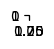

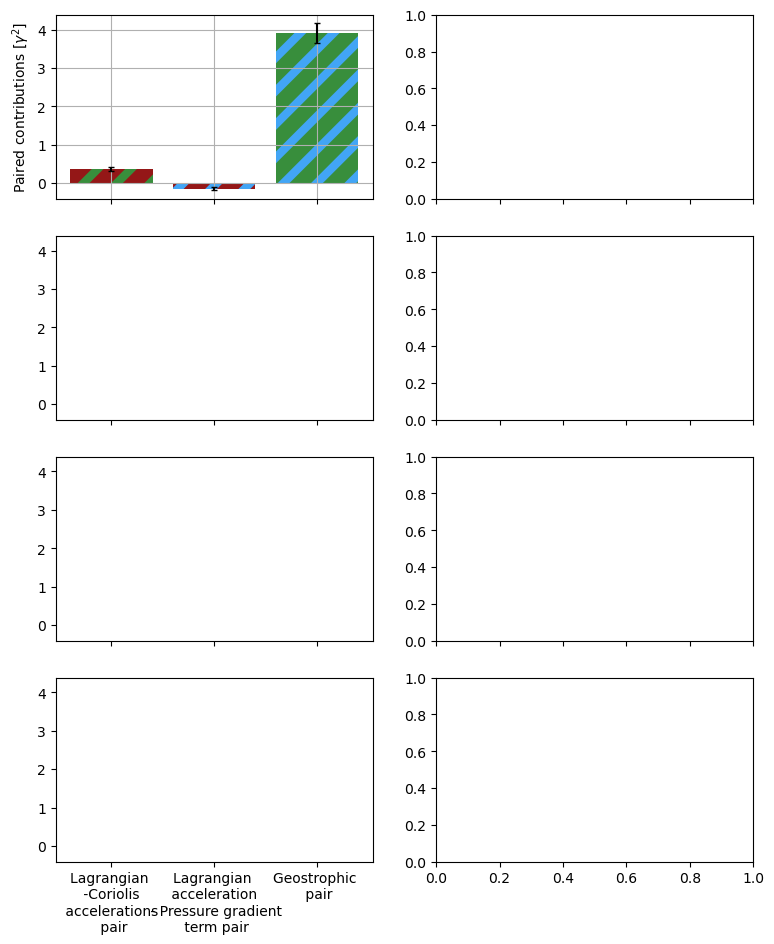

In [60]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
# ax.bar(0,1, color=c0['ggd'], label='Pressure gradient')
# ax.bar(0,1, color=c0['wd'], label='Wind term')
# ax.bar(0,1, color='lightgrey', label='Balanced Coriolis resolution mismatch error ?')
plt.rcParams["hatch.color"] = "lightgrey"
ax.bar(
    1,
    1,
    color=c0["cor"],
    alpha=0.5,
    hatch="/",
    label="Potential balance with Coriolis acceleration resolution mismatch error",
)

handles, labels = ax.get_legend_handles_labels()

plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(
    4, 2, frameon=False, figsize=(9, 11), sharex="col", sharey="col"
)

axs = axs.T.flatten()

# X_
plot_reserror_cor = False
plot_one_axis(dm, axs[0], plot_reserror_cor)
axs[0].set_title("Full dataset")
plot_one_axis(dma, axs[1], plot_reserror_cor)
axs[1].set_title("Anticyclones")
plot_one_axis(dmc, axs[2], plot_reserror_cor)
axs[2].set_title("Cyclones")
plot_one_axis(dn, axs[3], plot_reserror_cor)
axs[3].set_title("Other")

# Vorticity-strain diagram
binx = np.linspace(-0.2, 0.2, 50)
biny = np.linspace(0, 0.2, 50)
ax = axs[4]
plot_join_pdfs_one(df0_, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")
kwa = dict(
    c="r", bbox=dict(facecolor="w", edgecolor="none", pad=3.0), va="center", ha="center"
)


ax = axs[5]
plot_join_pdfs_one(dfa, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")
ax.set_ylim(0, 1.25)

ax = axs[6]
plot_join_pdfs_one(dfc, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")

ax = axs[7]
plot_join_pdfs_one(dfn, "vorticity_f", "strain_f", binx=binx, biny=biny, ax=ax)
ax.set_xlabel(r"Relative vorticity $\zeta/f$")
ax.set_ylabel(r"Relative strain $\sigma/|f|$")


for ax in axs[4:]:
    ax.annotate("AVD", (-0.15, 0.08), **kwa)
    ax.annotate("SD", (0, 0.12), **kwa)
    ax.annotate("CVD", (0.15, 0.08), **kwa)

axs[0].set_ylim(-1, 6.5)

l = ["a", "c", "e", "g", "b", "d", "f", "h"]
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

# fig.tight_layout()
fig.tight_layout(rect=[0, 0.02, 1, 1])
# fig.legend(handles, labels, ncol=3, loc="lower center")

### VELOCITIES STD ESTIMATIONS 

In [54]:
def velocities(dm, f, v):
    e = np.sqrt(dm[v] / (f**2) * U2 / 2)
    er = e * 1 / 2 * (dm["er__" + v] / dm[v])
    print(
        "Velocities "
        + v
        + f" :    {np.round(e.values*100, 1)[0]}\pm {np.round(er.values*100, 1)[0]} cm.s-1"
    )

In [55]:
velocities(dm, df0_.f.mean(), "B_acc"), velocities(
    dma, dfa.f.mean(), "B_acc"
), velocities(dmc, dfc.f.mean(), "B_acc"), velocities(dn, dfn.f.mean(), "B_acc")

Velocities B_acc :    2.3\pm 0.2 cm.s-1
Velocities B_acc :    3.4\pm 0.3 cm.s-1
Velocities B_acc :    1.5\pm 1.2 cm.s-1
Velocities B_acc :    1.7\pm 0.3 cm.s-1


(None, None, None, None)

In [56]:
velocities(dma, dfa.f.mean(), "B_ggd"), velocities(
    dmc, dfc.f.mean(), "B_ggd"
), velocities(dn, dfn.f.mean(), "B_ggd")

Velocities B_ggd :    10.3\pm 0.6 cm.s-1
Velocities B_ggd :    10.3\pm 1.5 cm.s-1
Velocities B_ggd :    10.3\pm 0.4 cm.s-1


(None, None, None)

In [57]:
velocities(dma, dfa.f.mean(), "B_wd"), velocities(
    dmc, dfc.f.mean(), "B_wd"
), velocities(dn, dfn.f.mean(), "B_wd")

Velocities B_wd :    5.9\pm 0.5 cm.s-1
Velocities B_wd :    3.1\pm 1.4 cm.s-1
Velocities B_wd :    6.2\pm 0.4 cm.s-1


(None, None, None)

TypeError: print_labels() takes 2 positional arguments but 3 were given

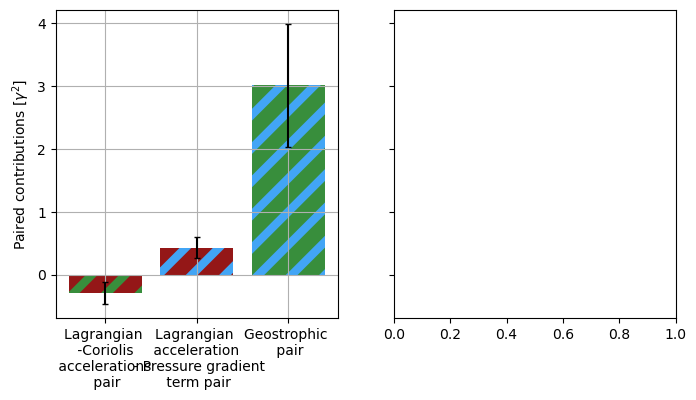

In [58]:
def print_labels(df, ax):
    S = df.X_cor_ggd
    l = ["X_acc_cor", "X_acc_ggd", "X_cor_ggd"]
    for i in [0, 1, 2]:
        X = l[i]
        label = (
            rf"{np.round(df[X].values[0], 2)}"
            + rf"$\pm$ {np.round(df['er__' + X].values[0], 2)}"
        )
        if i in [0, 1]:
            label = label + "\n" + f"{int(np.round((df[X]/S*100).values[0], 0))}%"
        ax.text(
            i,
            df[X].values + 0.5,
            label,
            horizontalalignment="center",
            verticalalignment="bottom",
            rotation=0,
        )


fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4), sharey="row")

axs = axs.flatten()

# X_
plot_one_axis(dmc, axs[0])
print_labels(dmc, axs[0])
axs[0].set_title("Cyclones")
plot_one_axis(dma, axs[1])
print_labels(dma, axs[1])
axs[1].set_title("Anticyclones")

fig.tight_layout()

In [ ]:
df = pd.concat([dma.to_dataframe(), dmc.to_dataframe(), dn.to_dataframe()], axis=0)

In [ ]:
for df in [df]:
    for X in [
        v
        for v in df.columns
        if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
    ]:
        df[X + "Total_percentage"] = df[X] / df.X_cor_ggd
        df["er__" + X + "Total_percentage"] = df[X + "Total_percentage"] * np.sqrt(
            ((df["er__" + X] / df[X]) ** 2 + (df["er__X_cor_ggd"] / df.X_cor_ggd) ** 2)
        )

In [ ]:
df[
    [
        X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

In [ ]:
df[
    [
        "er__" + X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

In [ ]:
df["X_acc_cor"] / df["COR"] / 2

In [ ]:
df["X_acc_cor"] / df["COR"] / 2 * np.sqrt(
    (df["er__X_acc_cor"] / df["X_acc_cor"]) ** 2 + (df["er__COR"] / df["COR"]) ** 2
)

In [ ]:
df["X_acc_ggd"] / df["GGD"] / 2

In [ ]:
df["X_acc_ggd"] / df["GGD"] / 2 * np.sqrt(
    (df["er__X_acc_ggd"] / df["X_acc_ggd"]) ** 2 + (df["er__GGD"] / df["GGD"]) ** 2
)

In [ ]:
df["X_acc_ggd"] / df["B_ggd"] / 2

# Diagram vorticity/strain

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), frameon=False)

ax = axs[0]
plot_join_pdfs_one(
    dfc,
    "vorticity_f",
    "strain_f",
    binx=np.linspace(-1.5, 1.5, 50),
    biny=np.linspace(0, 2, 50),
    ax=ax,
)
ax.set_xlabel(r"$\zeta/f$")
ax.set_ylabel(r"$\sigma/|f|$")

import matplotlib.patches as patches

# Create a Rectangle patch
rect = patches.Rectangle(
    (-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor="r", facecolor="none", zorder=10
)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate("AVD", (-1.2, 0.6), c="r")
ax.annotate("SD", (0, 1.1), c="r")
ax.annotate("CVD", (1.2, 0.6), c="r")

ax.set_title("Cyclones")
ax.set_ylim(0, 1.25)

ax = axs[1]
plot_join_pdfs_one(
    dfa,
    "vorticity_f",
    "strain_f",
    binx=np.linspace(-1.5, 1.5, 50),
    biny=np.linspace(0, 2, 50),
    ax=ax,
)
ax.set_xlabel(r"$\zeta/f$")
ax.set_ylabel(r"$\sigma/|f|$")

import matplotlib.patches as patches

# Create a Rectangle patch
rect = patches.Rectangle(
    (-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor="r", facecolor="none", zorder=10
)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate("AVD", (-1.2, 0.6), c="r")
ax.annotate("SD", (0, 1.1), c="r")
ax.annotate("CVD", (1.3, 0.6), c="r")

ax.set_title("Anticyclones")

ax.set_ylim(0, 1.25)

fig.tight_layout()
# fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), frameon=False)

ax = axs[0]
plot_join_pdfs_one(
    dfc,
    "vorticity_f",
    "strain_f",
    binx=np.linspace(-1.5, 1.5, 50),
    biny=np.linspace(0, 2, 50),
    ax=ax,
)
ax.set_xlabel(r"$\zeta/f$")
ax.set_ylabel(r"$\sigma/|f|$")

import matplotlib.patches as patches

# Create a Rectangle patch
rect = patches.Rectangle(
    (-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor="r", facecolor="none", zorder=10
)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate("AVD", (-1.2, 0.6), c="r")
ax.annotate("SD", (0, 1.1), c="r")
ax.annotate("CVD", (1.2, 0.6), c="r")

ax.set_title("Cyclones")
ax.set_ylim(0, 1.25)

ax = axs[1]
plot_join_pdfs_one(
    dfa,
    "vorticity_f",
    "strain_f",
    binx=np.linspace(-1.5, 1.5, 50),
    biny=np.linspace(0, 2, 50),
    ax=ax,
)
ax.set_xlabel(r"$\zeta/f$")
ax.set_ylabel(r"$\sigma/|f|$")

import matplotlib.patches as patches

# Create a Rectangle patch
rect = patches.Rectangle(
    (-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor="r", facecolor="none", zorder=10
)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate("AVD", (-1.2, 0.6), c="r")
ax.annotate("SD", (0, 1.1), c="r")
ax.annotate("CVD", (1.3, 0.6), c="r")

ax.set_title("Anticyclones")

ax.set_ylim(0, 1.25)

fig.tight_layout()
# fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))